In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

# Easy

**Точечное изображение** — это математическая модель динамической системы с дискретным временем, заданная рекуррентным соотношением:
$$\vec{x}_{n+1} = \vec{f}(\vec{x}_{n}),$$
где $\vec{x}_{n}$ — вектор состояния в момент $n$, $\vec{f}$ — отображение,
определяющее переход к следующему состоянию.

Для задания рассмотрим одномерное логистическое отображение:
$$x_{n+1} = rx_n(1 - x_n), x \in (0, 1) \ r \in (0, 4]$$

##### Easy:

Докажите, что $\forall n \in \mathbb{N}, \forall r \in (0;1]$
$$0 < x_0 < 1 \Longrightarrow 0 < x_n < 1$$

Докажем утверждение с помощью метода математической индукции.

База индукции:
$$0 < x_0 < 1$$
 $$x_1 = rx_0(1 - x_0)$$
 $$0 < x_0 \Longrightarrow r * 0 * 1 = 0 < x_1$$
 $$0 < x_0 < 1 \Longleftrightarrow 1 > 1 - x_0 > 0 \Rightarrow x_1 < r * 1 * 1 < r < 1$$
 $$0 < x_1 < 1$$

Индукционный переход:

По аналогии с "База индукции" доказывается, что
$$0 < x_n < 1 \Longrightarrow 0 < x_{n+1} < 1$$

##### Easy:

Для заданной вариантом функции $g(x_n)$:
1. Постройте графики зависимости $x_n$ от $x_{n−1}$ для нескольких различных значений r.
2. Сделайте вывод о сходстве или различии поведения логистического отображения и точечного отображения. Предположите: чем могут быть вызваны сходства/различия?

In [3]:
def f(x, r):
    """Логистическое отображение: $x_{n+1} = rx_n(1-x_n)$"""
    return r * x * (1 - x)

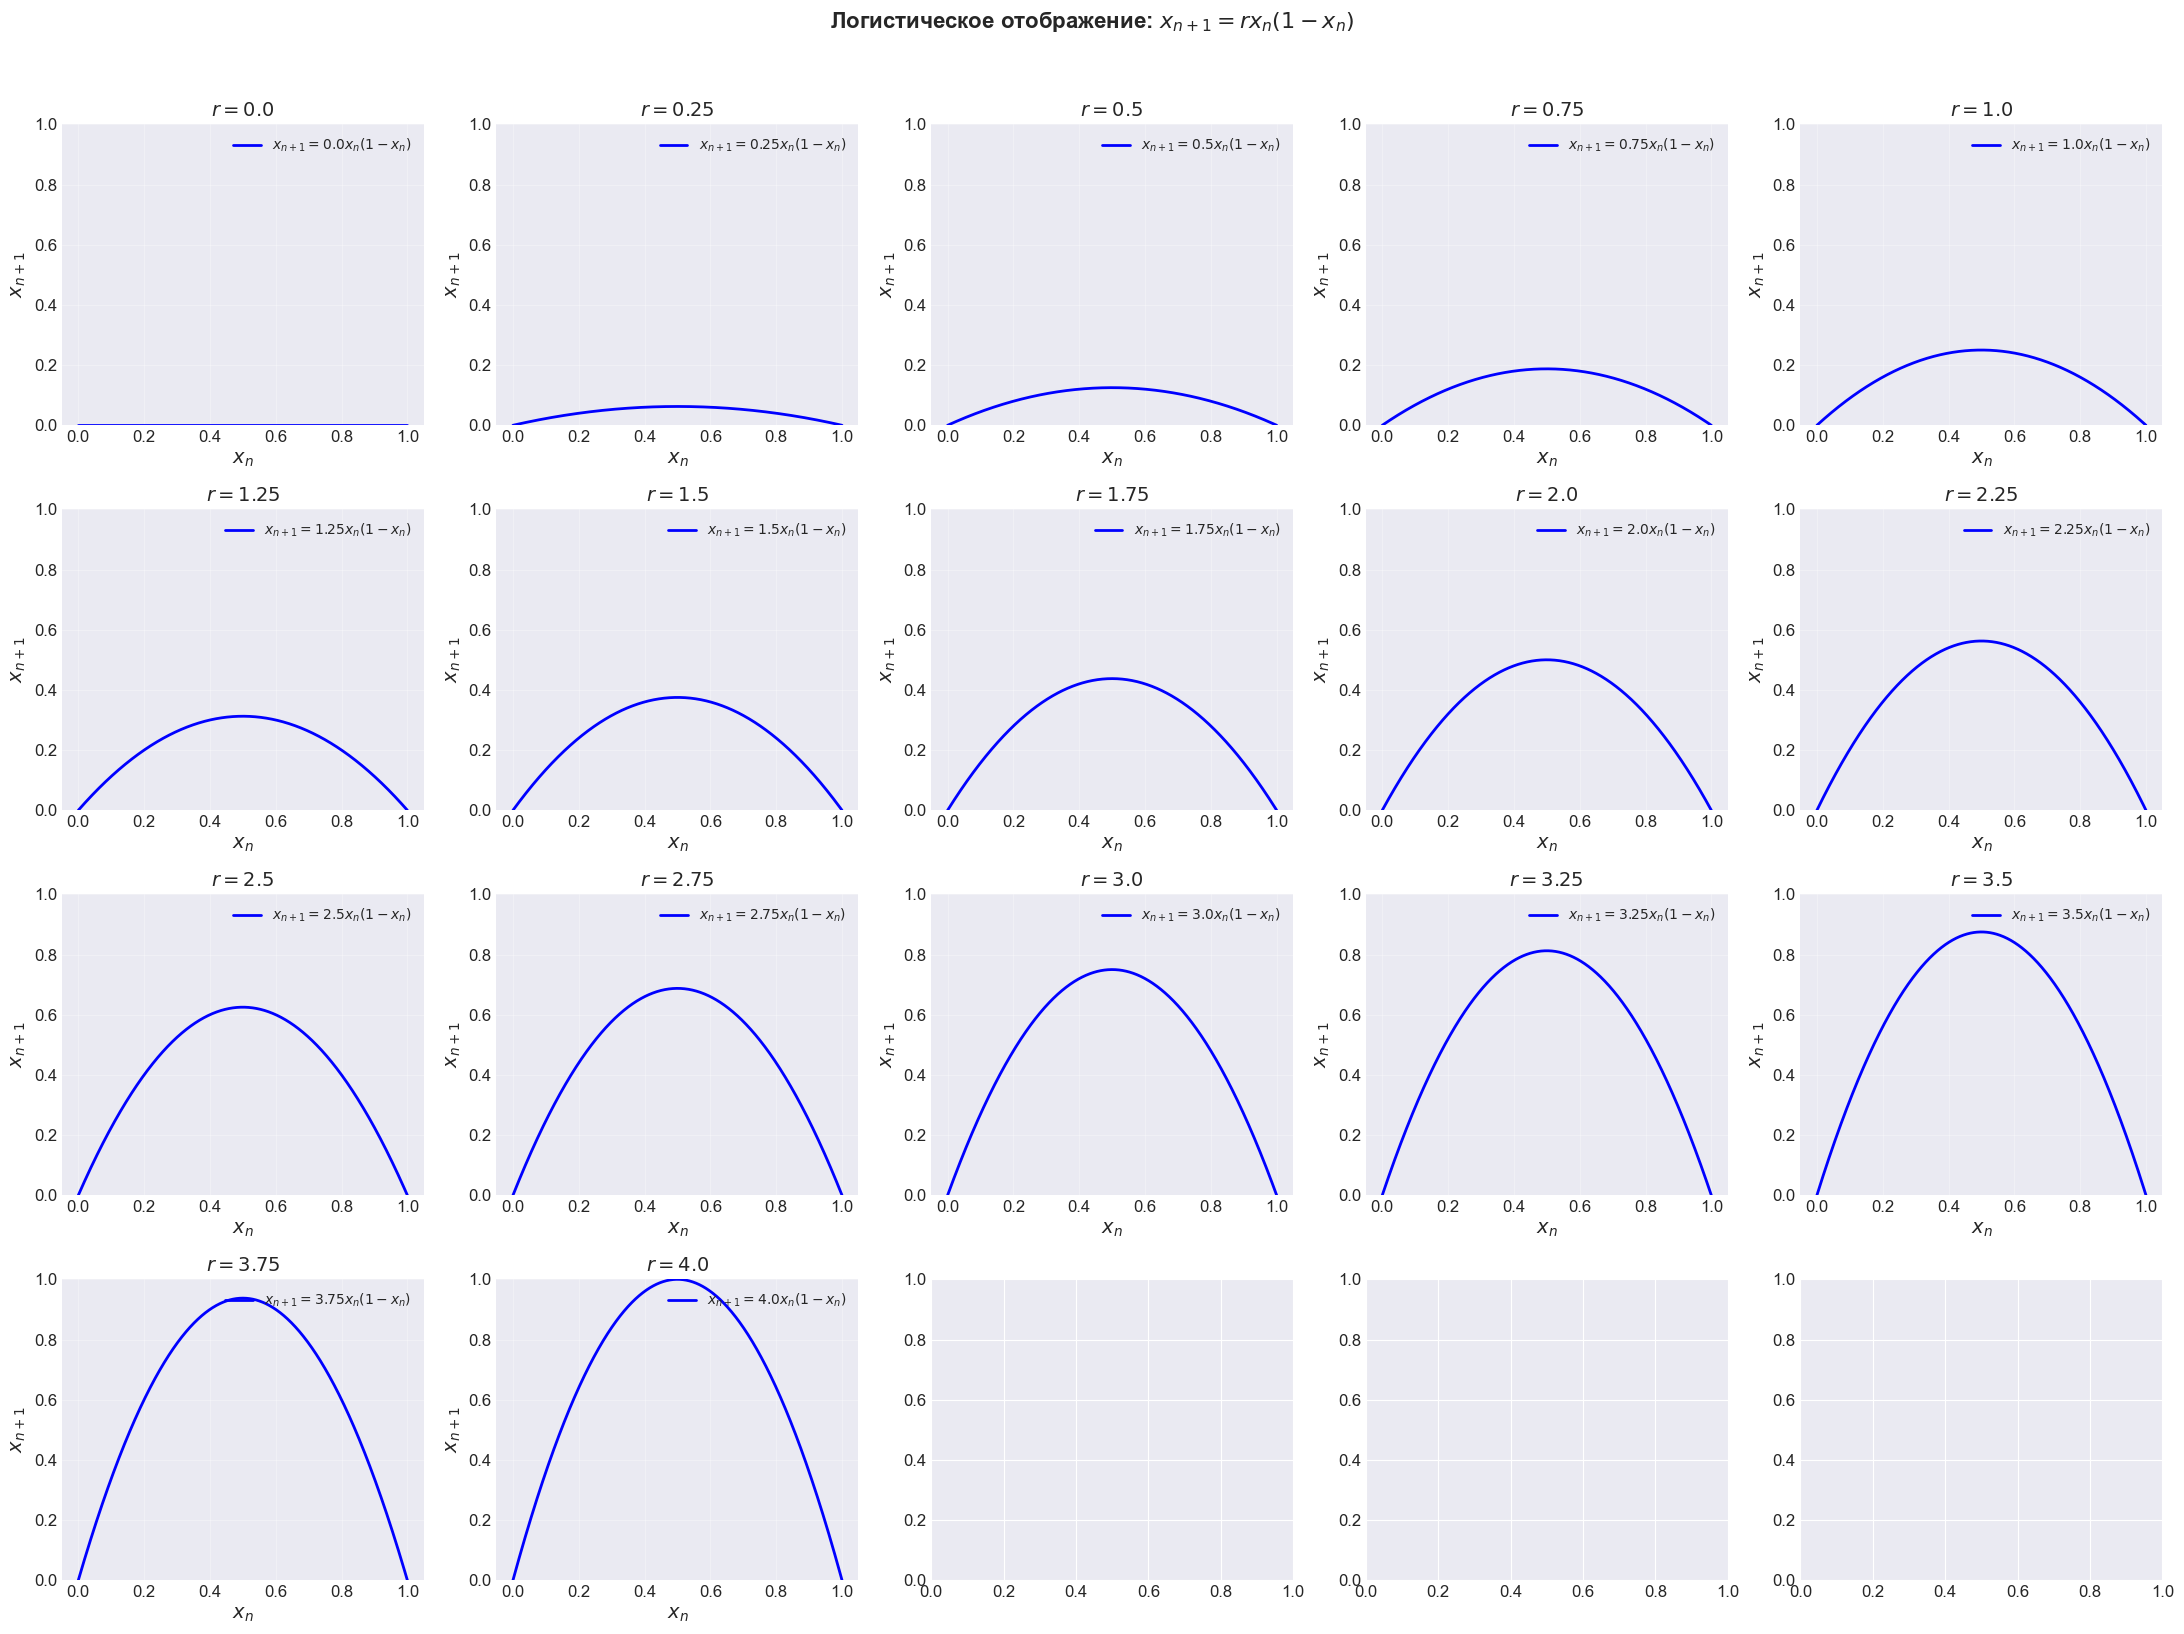

In [4]:
x0_values = np.arange(0, 1.1, 0.1)
r_values = np.arange(0, 4.25, 0.25)  # 17

len_r_values = len(r_values)

fig, axes = plt.subplots(4, 5, figsize=(22, 16))

for idx, (r, ax) in enumerate(zip(r_values, axes.flatten())):
    # Значение x от 0 до 1 с шагом 1000
    x = np.linspace(0, 1, 1000)

    # Считаем для каждого x_n x_{n+1}
    x_next = f(x, r)

    # Рисуем функцию перехода
    ax.plot(x, x_next, 'b-', linewidth=2, label=f'$x_{{n+1}} = {r}x_n(1-x_n)$')

    ax.set_ylim(0, 1)
    ax.set_xlabel('$x_n$', fontsize=14)
    ax.set_ylabel('$x_{n+1}$', fontsize=14)
    ax.set_title(f'$r = {r}$', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    ax.legend(loc='upper right', fontsize=10)

plt.suptitle(f.__doc__, fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

$f(x) = rx(1 - x) = r(-x^2 + x) = r(-(x-\frac{1}{2})^2 + \frac{1}{4})$ - парабола с ветвями вниз c $x_0 = 0.5$ и $y_0 = \frac{r}{4}$

Параметр $r$ растягивает $f$ по оси $Y$, увеличивая её максимальное значение функции.

$N = {ISU} \mod 5 = 501679 \mod 5 = 4$ - вариант лабораторной работы.
$$g(x_{n+1}) = rx_n(1 - x_n)(2 - x_n), r \in (0, \frac{3\sqrt3}{2}], x \in [0, 1]$$

In [5]:
def g(x, r):
    """Точечное отображение: $g(x_{n+1}) = rx_n(1 - x_n)(2 - x_n)$"""
    return r * x * (1 - x) * (2 - x)

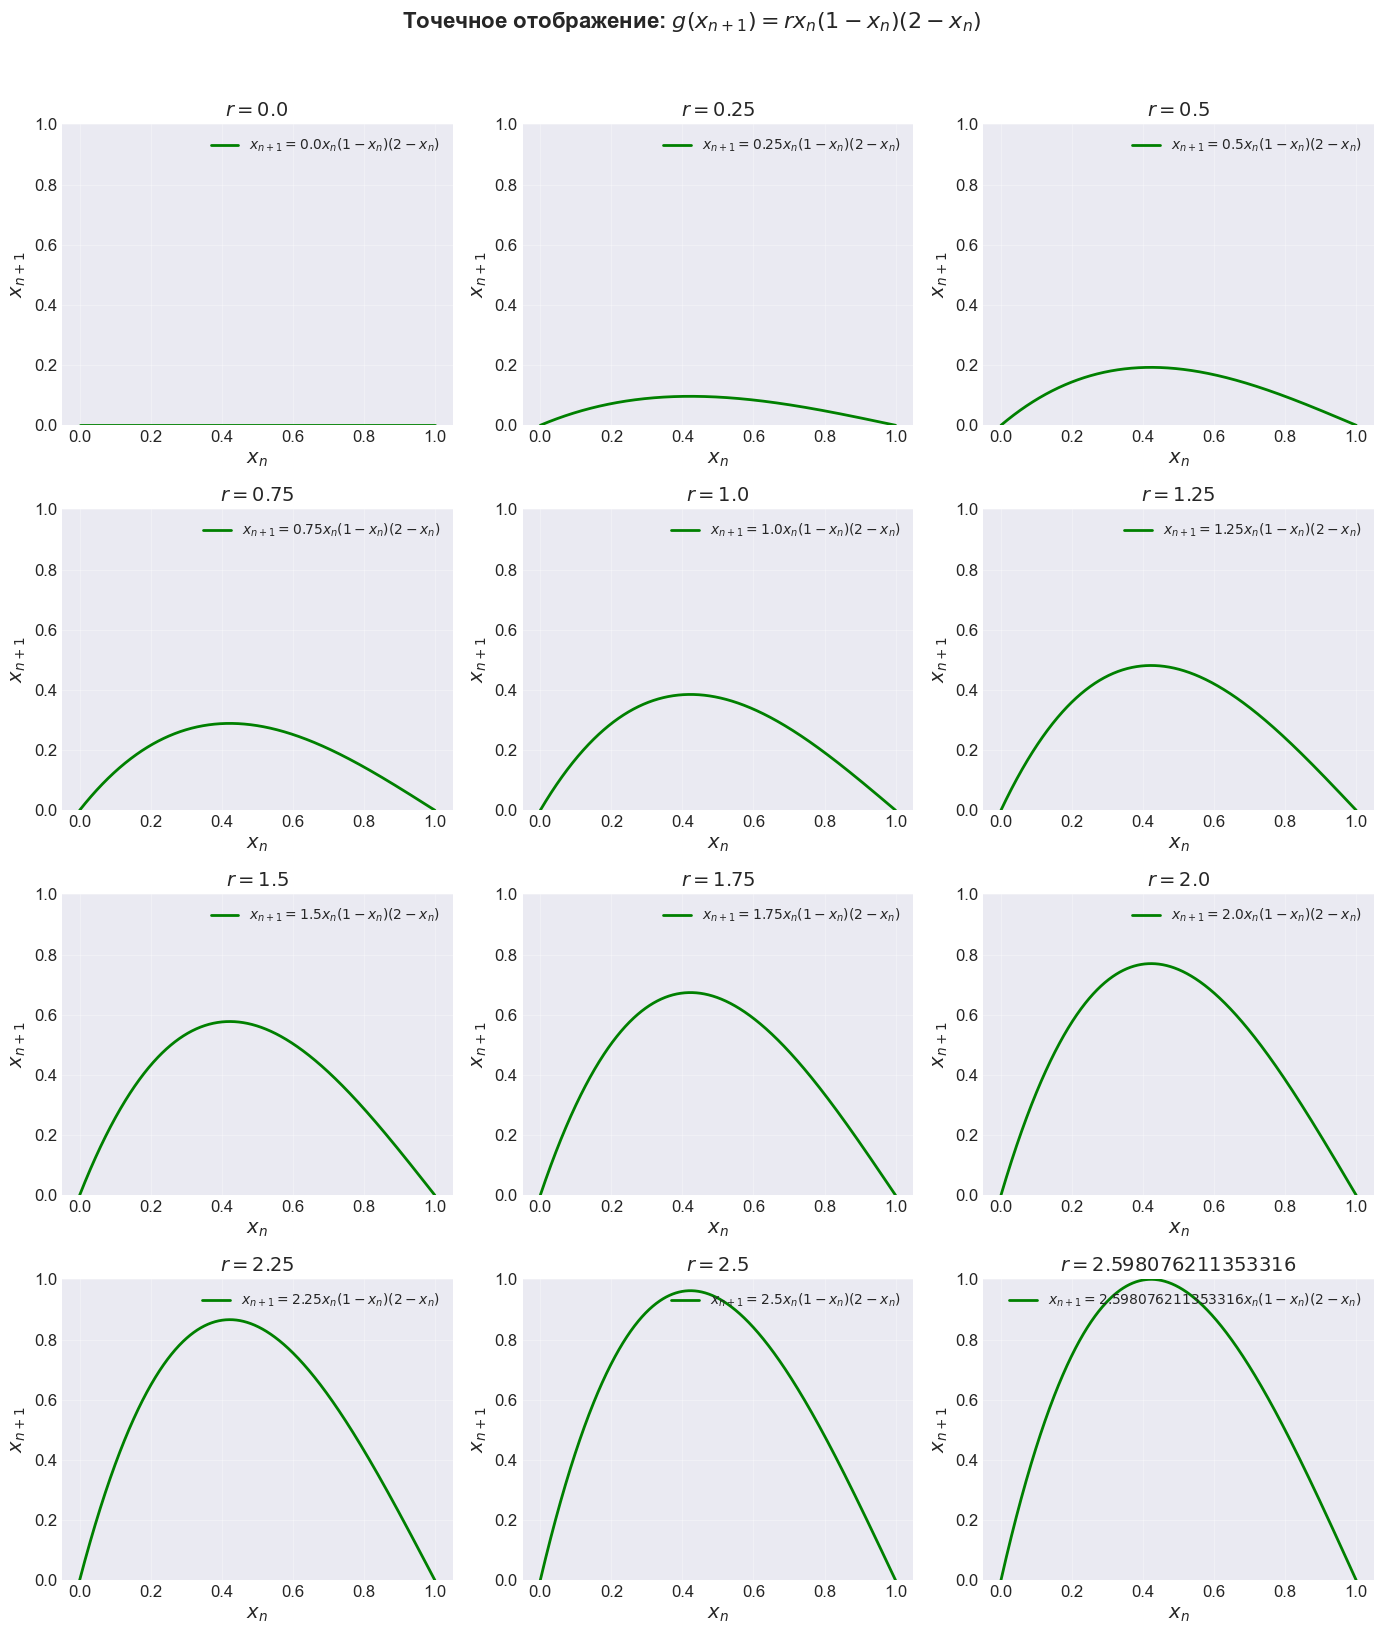

In [8]:
from math import sqrt


r_limit = 3 * sqrt(3) / 2

x0_values = np.arange(0, 1.1, 0.1)
r_values = np.arange(0, r_limit, 0.25)
r_values = np.append(r_values, r_limit)  # 12

len_r_values = len(r_values)

fig, axes = plt.subplots(4, 3, figsize=(14, 16))

for idx, (r, ax) in enumerate(zip(r_values, axes.flatten())):
    # Значение x от 0 до 1 с шагом 1000
    x = np.linspace(0, 1, 1000)

    # Считаем для каждого x_n x_{n+1}
    x_next = g(x, r)

    # Рисуем функцию перехода
    ax.plot(x, x_next, 'g-', linewidth=2, label=f'$x_{{n+1}} = {r}x_n(1-x_n)(2-x_n)$')

    ax.set_ylim(0, 1)
    ax.set_xlabel('$x_n$', fontsize=14)
    ax.set_ylabel('$x_{n+1}$', fontsize=14)
    ax.set_title(f'$r = {r}$', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    ax.legend(loc='upper right', fontsize=10)

plt.suptitle(g.__doc__, fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

$$g(x) = rx(1 - x)(2 - x) = rx(x - 1)(x - 2) = rx(x^2 - 3x + 2) = r(x^3 - 3x^2 + 2x) \text{ — степенная функция с показателем степени 3}$$

Графики $f(x_n)$ и $g(f_n)$ довольно схожи, так как
* $g(x) = f(x)(2 - x)$, при $1 < 2 - x < 2 \Longleftrightarrow f(x) < g(x) < 2f(x)$,
* обе являются степенными функциями.


# Normal


Найдём точку максимального значения $g(x) = y_0$, при $x \in [0, 1]$:

$$g'(x) = r(3x^2 - 6x + 2) = r(3(x - 2x + 1) - 1) = r(3(x - 1)^2 - 1)$$
$$g'(x_0) = 0 \text{, где } x_0 \text{ — точка перегиба}$$
$$g'(x_0) = r(3(x_0 - 1)^2 - 1) = 0 \Longrightarrow x_0 = 1 \pm\frac{\sqrt{3}}{3}$$
$$\begin{cases}
    x_0 = \pm\frac{\sqrt{3}}{3} + 1 \\
    x \in [0,1] \\
\end{cases} \Longrightarrow x_0 = 1 - \frac{\sqrt{3}}{3} \Longrightarrow y_0 = \frac{2\sqrt{3}r}{9}$$

Поведение функции в зависимости от $r \in (0, 4]$:
* При $r <= 1$, $f$ независимо от $x_0$ стремиться к 0
* При $r \in (1, 3)$, $f$ стремится к стабильной точке $1 - \frac{1}{r}$
* При $r \in [3, \thickapprox3.57)$, $f$ образует цикл
* При $r \in [\thickapprox3.57, 4]$, $f$ ведёт себя хаотично

# Hard

# Extreme